In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             classification_report, roc_curve, auc)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Set plot style
plt.style.use('ggplot')
shap.initjs()

In [38]:
# Load data
train_df = pd.read_csv("GiveMeSomeCredit/cs-training.csv").drop(columns=['Unnamed: 0'])

# Initial Look
print(f"Dataset Shape: {train_df.shape}")
print(f"Target Distribution:\n{train_df['SeriousDlqin2yrs'].value_counts(normalize=True)}")

# Define Target and Features
X = train_df.drop(columns=['SeriousDlqin2yrs'])
y = train_df['SeriousDlqin2yrs']

Dataset Shape: (150000, 11)
Target Distribution:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [39]:
def add_custom_features(df):
    df = df.copy()
    # 1. Total times late (combined metric)
    df['TotalTimeLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] + 
                           df['NumberOfTime60-89DaysPastDueNotWorse'] + 
                           df['NumberOfTimes90DaysLate'])
    
    # 2. Monthly Income per person in household
    # Fill NA temporarily for the ratio calculation
    temp_income = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
    df['IncomePerPerson'] = temp_income / (df['NumberOfDependents'].fillna(0) + 1)
    
    # 3. Log transforms for skewed data (helps Logistic Regression/KNN)
    df['LogMonthlyIncome'] = np.log1p(df['MonthlyIncome'].fillna(0))
    
    return df

X_engineered = add_custom_features(X)

# Split into Train and Validation sets (Stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_engineered, y, test_size=0.2, stratify=y, random_state=42
)

In [40]:
# Calculate ratio for XGBoost
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Models and Parameter Grids
model_configs = [
    {
        'name': 'Logistic Regression',
        'pipeline': Pipeline([('imp', SimpleImputer(strategy='median')), ('std', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))]),
        'params': {'clf__C': [0.1, 1, 10]}
    },
    {
        'name': 'XGBoost',
        'pipeline': Pipeline([('imp', SimpleImputer(strategy='median')), ('std', StandardScaler()), ('clf', XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42))]),
        'params': {'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]}
    },
    {
        'name': 'Random Forest',
        'pipeline': Pipeline([('imp', SimpleImputer(strategy='median')), ('std', StandardScaler()), ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))]),
        'params': {'clf__n_estimators': [100, 200], 'clf__max_depth': [5, 10]}
    }
]

# Run GridSearchCV
best_models = {}
for config in model_configs:
    print(f"Tuning {config['name']}...")
    grid = GridSearchCV(config['pipeline'], config['params'], cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[config['name']] = grid.best_estimator_

Tuning Logistic Regression...
Tuning XGBoost...
Tuning Random Forest...


In [41]:
metrics_list = []

for name, model in best_models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'F1 Score': f1_score(y_val, y_pred),
        'AUC-ROC': roc_auc_score(y_val, y_prob)
    })

results_df = pd.DataFrame(metrics_list).sort_values(by='AUC-ROC', ascending=False)
print(results_df)

                 Model  Accuracy  F1 Score   AUC-ROC
1              XGBoost  0.792933  0.336750  0.868770
2        Random Forest  0.815367  0.350569  0.862095
0  Logistic Regression  0.773067  0.282311  0.802468


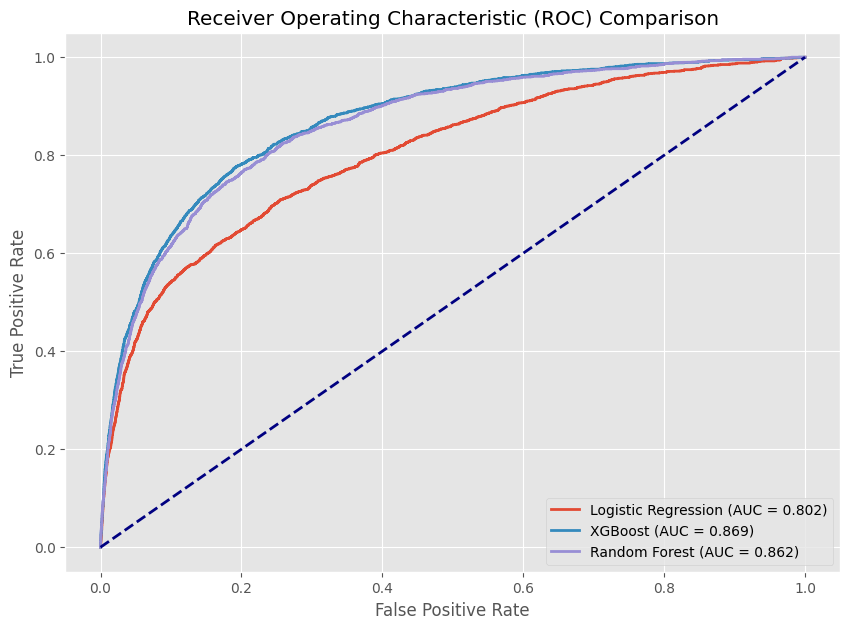

In [42]:
plt.figure(figsize=(10, 7))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()

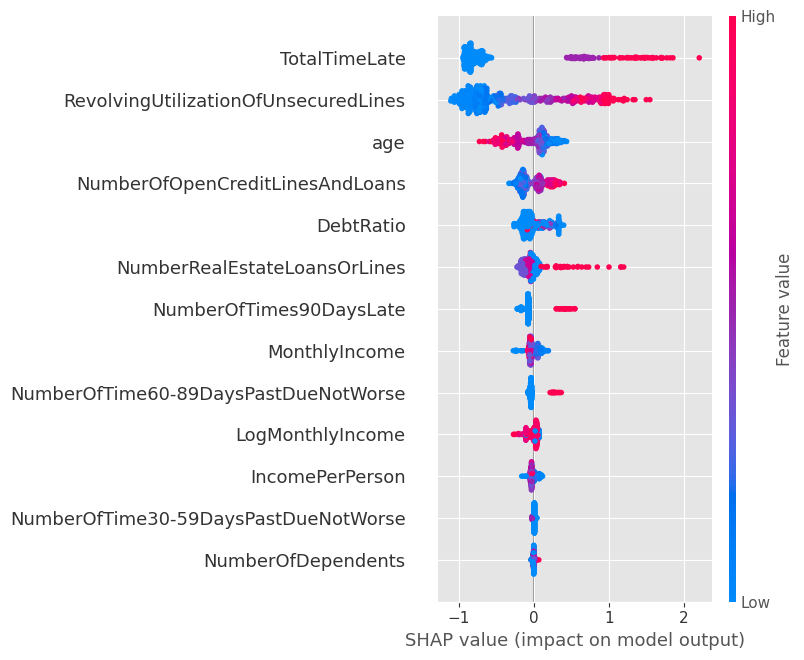

In [43]:
# Extract the internal model from the pipeline
best_name = results_df.iloc[0]['Model']
best_pipe = best_models[best_name]
final_model = best_pipe.named_steps['clf']
preprocessor = Pipeline(steps=best_pipe.steps[:-1])

# Transform data for SHAP
X_val_transformed = preprocessor.transform(X_val[:500])
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_transformed)

# Plot summary
shap.summary_plot(shap_values, X_val_transformed, feature_names=X_engineered.columns)